In [1]:
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

from models.dcgan import Generator
from models.cnn_rnn import CNNRNNEncoder

from data.tokenizer import Tokenizer

from utils.utils import add_padding

In [2]:
tokenizer = Tokenizer()
VOCAB_SIZE = len(tokenizer)
PAD_VALUE = tokenizer.pad_token_id
CTX_LENGTH = 201

In [3]:
generator = Generator(ngf=196)
generator.load_state_dict(torch.load('./checkpoints/weights_generator.pth', weights_only=True,map_location=torch.device('cpu')))

<All keys matched successfully>

In [4]:
text_encoder = CNNRNNEncoder(len(tokenizer))
text_encoder.load_state_dict(torch.load('./cnn_rnn_checkpoints/weights_cnn_rnn.pth', weights_only=True, map_location=torch.device('cpu')))

<All keys matched successfully>

In [5]:
generator.eval()
text_encoder.eval()

CNNRNNEncoder(
  (cnn): Sequential(
    (0): Conv1d(70, 384, kernel_size=(4,), stride=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(384, 512, kernel_size=(4,), stride=(1,))
    (4): ReLU(inplace=True)
    (5): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(512, 512, kernel_size=(4,), stride=(1,))
    (7): ReLU(inplace=True)
  )
  (gru): GRU(512, 512, batch_first=True)
  (out): Linear(in_features=512, out_features=1024, bias=True)
)

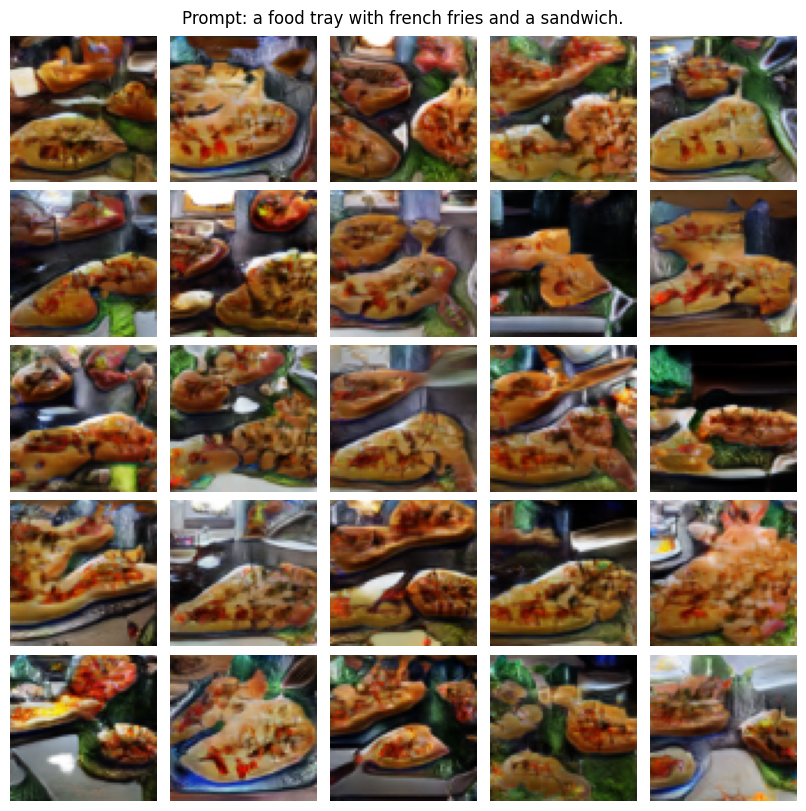

In [6]:
prompt = 'a food tray with french fries and a sandwich.'    # string of length n
tokens = tokenizer.encode(prompt)                           # list of n integers
tokens = torch.Tensor(tokens).long()                        # shape [n,]
tokens = add_padding(tokens, PAD_VALUE, CTX_LENGTH)         # shape [CTX_LENGTH,]
tokens = F.one_hot(tokens, num_classes=VOCAB_SIZE).float()  # shape [CTX_LENGTH, VOCAB_SIZE]
tokens = tokens.transpose(1, 0)                             # shape [VOCAB_SIZE, CTX_LENGTH]
tokens = tokens.unsqueeze(0)                                # shape [1, VOCAB_SIZE, CTX_LENGTH]
embedding = text_encoder(tokens)                            # shape [1, 1024]

fig, ax = plt.subplots(ncols=5, nrows=5, figsize=(8, 8), constrained_layout=True)
ax = ax.flatten()
fig.suptitle(f'Prompt: {prompt}')
for i in range(25):
    z = torch.randn(size=(1, 100, 1, 1))
    img = generator(z, embedding)
    img = (img.squeeze(0).detach().numpy().transpose(1, 2, 0) + 1) / 2
    ax[i].imshow(img)
    ax[i].axis('off')
plt.show()